# Clustering

En este cuaderno se comprobarán 3 tipos distintos de clustering, el clusterin por agrupaciones con el método k-means, el clustering jerárquico con el agglomerative clustering y el clustering basado en densidad con el DBSCAN para ver sus particularidades y pensar en cual nos puede venir mejor para nuestro proyecto.

## 1. k-Means (Agrupamiento por particiones)
### ¿Qué es?
Es uno de los métodos de agrupamiento clásicos y trata de dividir el conjunto de datos en k subconjuntos rígido siendo k un valor que definiremos y dependiendo de el problema bien podrémos hacernos una idea de cuantos son o bien nos tocará probar y optimizar el resultado.

### ¿Cómo funciona?
1.  En este método se eligen al azar k puntos de nuestro espacio de datos, puntos los cuales llamaremos centroides y a los cuales se les unirán los puntos más cercanos en el espacio de datos.
2.  Tras esto se transladará el centroide al punto medio de los datos que hayan caído en ese agrupamiento (cluster).
3.  Finalmente se repetirá el proceso de agrupamiento con el nuevo centroide repitiendo este proceso hasta que los datos dejen de cambiar de grupo.

### Situaciones de uso
Viene muy bien en general cuando los grupos están bien delimitados o mejor aún cuando en el espacio los grupos se forman de manera esférica y clara.




In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA

# 1. Cargar los datasets exportados
X_df = pd.read_csv('../dataset/X_vulnerabilidad_info.csv')
y = pd.read_csv('../dataset/y_vulnerabilidad.csv').squeeze()

# 2. Separar metadatos de las variables predictoras
id_cols = ['Country Name', 'Country Code', 'Time']
X_features = X_df.drop(columns=id_cols)
metadata = X_df[id_cols].copy()

# 3. Estandarizar las variables predictoras
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# 4. K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
metadata['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)
print("¡Clustering K-Means aplicado!")
print(metadata['Cluster_KMeans'].value_counts())

¡Clustering K-Means aplicado!
Cluster_KMeans
0    2013
3    1927
1    1520
2    1404
Name: count, dtype: int64


## 2. Clustering Aglomerativo (jerárquico)
### ¿Qué es?
Construye un dendrograma (un árbol jerárquico) que nos muestras como se relacionan los puntos desde lo más específico a lo más general.

### ¿Cómo funciona?
1.  Comienza seleccionando todos los datos del espacio muestral y calcula sus valores en este caso de varianza (en este caso usamos el métod ward que utiliza la varianza como criterio de cercanía).
2.  Los paises con el criterio de cercanía más cercanos (la varianza en este caso) los une para formar el nivel superior.
3.  Continua realizando el mismo proceso fusionando con los subconjuntos que se generan hasta llegar a los últimos conjuntos más globales (en este caso 4 agrupamientos).

### Situaciones de uso
Es útil cuando no solo tratamos de separar sino además tratamos de ver las similitudes (en este caso socioeconómicas) de los datos y qué bloques mantienen comportamientos similares.

In [7]:
# 5. Clustering Jerárquico (Agglomerative Clustering)
# Usamos 'ward' linkage, que minimiza la varianza dentro de los clusters
agg_clustering = AgglomerativeClustering(n_clusters=4, linkage='ward')
metadata['Cluster_Jerarquico'] = agg_clustering.fit_predict(X_scaled)
print("\n¡Clustering Jerárquico aplicado!")
print(metadata['Cluster_Jerarquico'].value_counts())


¡Clustering Jerárquico aplicado!
Cluster_Jerarquico
1    2985
0    2016
2    1283
3     580
Name: count, dtype: int64


## 2. Clustering DBSCAN (Agrupamiento basádo en densidad)
### ¿Qué es?
`Density-Based Spatial Clustering of Applicationswith Noise` (o DBSCAN). Es un enfoque en el que no se cierran los grupos de una manera fija sino que se trata de observar zonas en las que los datos se agrupan con una mayor densidad, asilando después la periferia.

### ¿Cómo funciona?
1.  Se le da una distancia de busqueda (eps) y el número minimo de vecinos.
2.  Va recorriendo los datos y observanco la cercania entre ellso para comprobar si es lo suficientemente cercana como por que formen un cluster o se añada a alguno de los ya existente.
3.  En caso de encontrarse un dato muy aislado de el resto los va agrupando en un conuunto de ruido (normalmente denominado -1).

### Situaciones de uso
Es muy conveniente cuando hay situaciones atípicas ya que se le da bien detectar estas. En este caso podría ser muy útil para detectar los principales agrupamientos típicos y dejar asilados agrupamientos que sean atípicos como paraísos fiscales, paises con poca o nula transparencia real, etc.

In [8]:
# 6. DBSCAN
# eps: la distancia máxima entre dos muestras para que una se considere en la vecindad de la otra.
# min_samples: el número de muestras en una vecindad para que un punto se considere un punto central.
# Nota: DBSCAN no requiere que especifiques el número de clusters.
dbscan = DBSCAN(eps=5, min_samples=10) 
metadata['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)
print("\n¡Clustering DBSCAN aplicado!")
print(metadata['Cluster_DBSCAN'].value_counts())
# Nota: En DBSCAN, el cluster '-1' representa ruido (outliers).


¡Clustering DBSCAN aplicado!
Cluster_DBSCAN
 1    6434
-1     243
 4      47
 8      24
 3      23
 0      21
 5      18
 7      18
 2      14
 9      12
 6      10
Name: count, dtype: int64


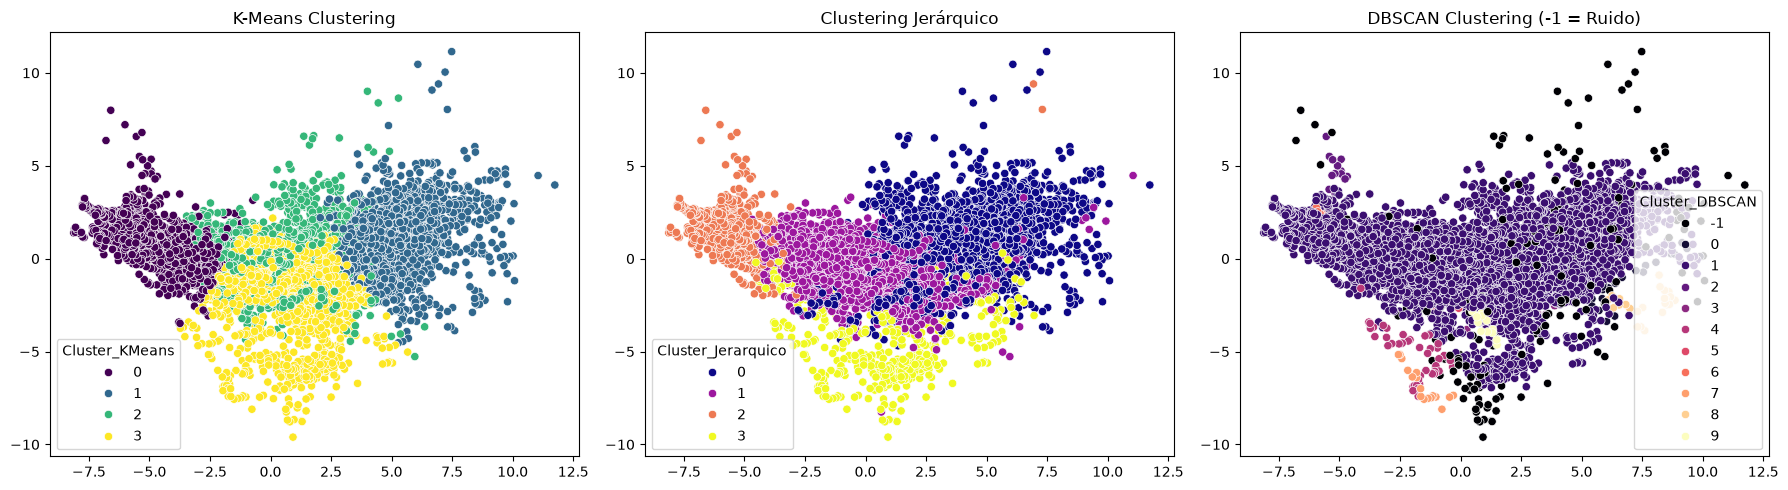

In [9]:
# 7. Visualización usando PCA (para reducir a 2D y poder graficar)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot K-Means
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=metadata['Cluster_KMeans'], palette='viridis', ax=axes[0], legend='full')
axes[0].set_title('K-Means Clustering')

# Plot Jerárquico
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=metadata['Cluster_Jerarquico'], palette='plasma', ax=axes[1], legend='full')
axes[1].set_title('Clustering Jerárquico')

# Plot DBSCAN
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=metadata['Cluster_DBSCAN'], palette='magma', ax=axes[2], legend='full')
axes[2].set_title('DBSCAN Clustering (-1 = Ruido)')

plt.tight_layout()
plt.show()

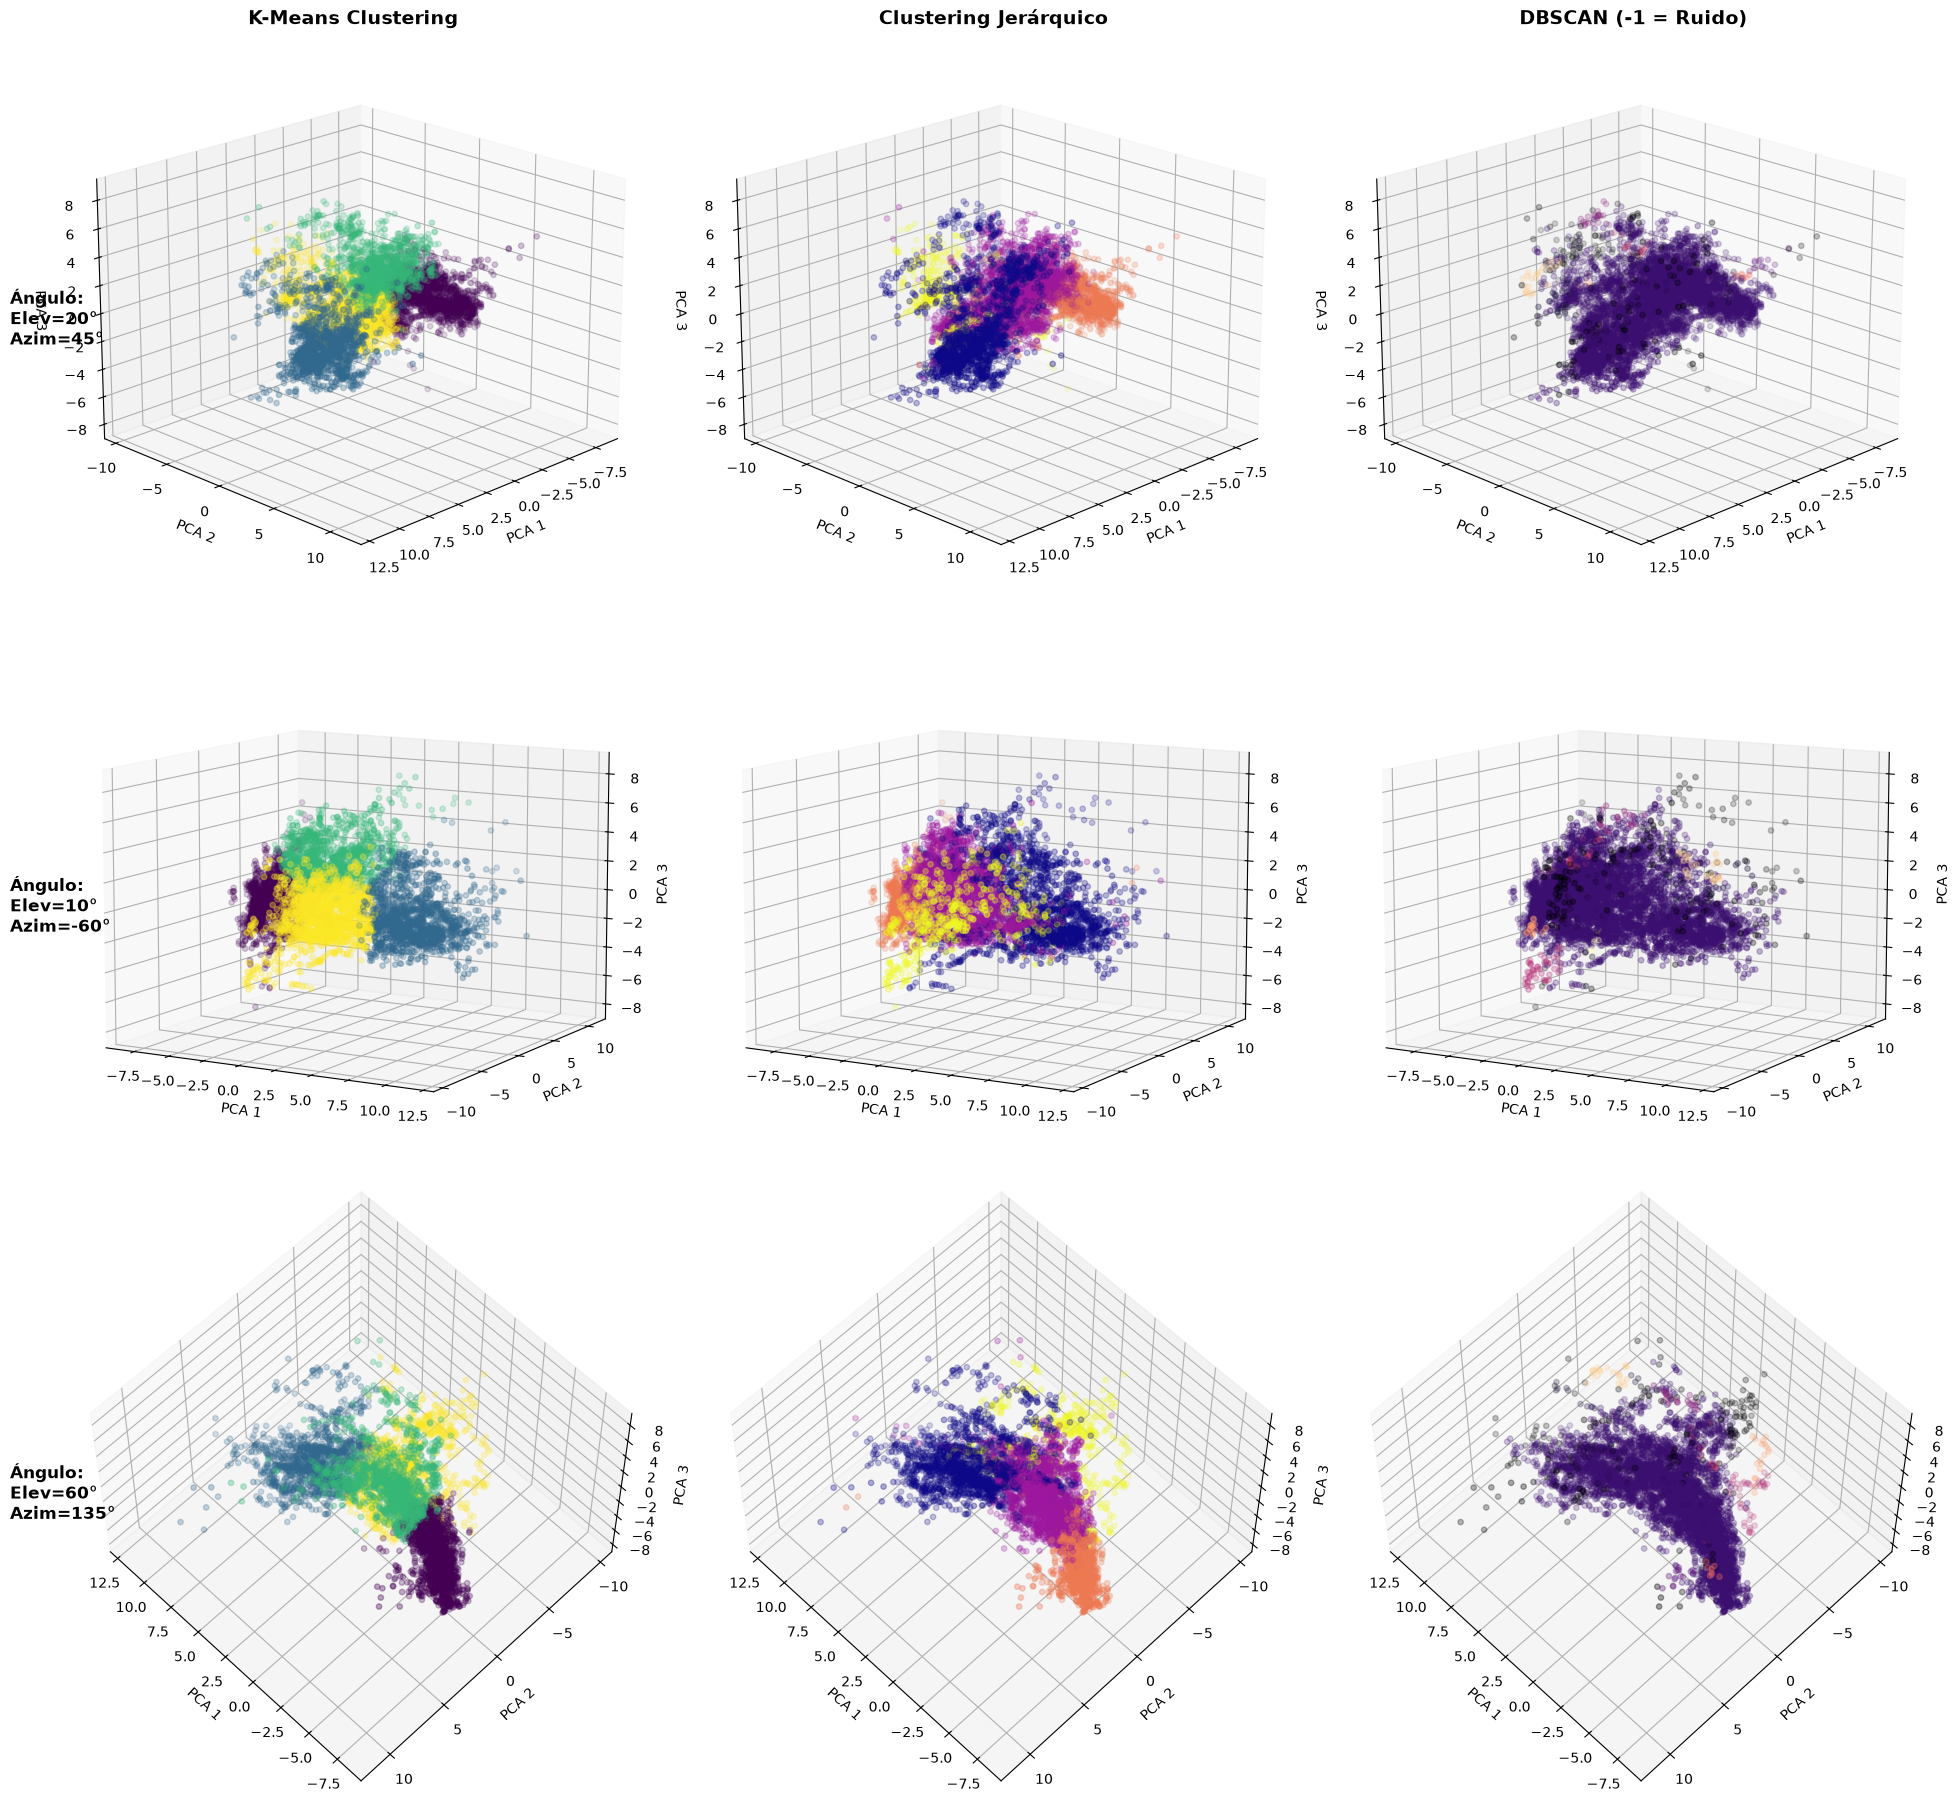

In [12]:
# ==============================================================================
# 8. VISUALIZACIÓN 3D MÚLTIPLES PERSPECTIVAS (CUADRÍCULA 3x3)
# ==============================================================================
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Extraemos 3 componentes principales
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# Definimos los 3 ángulos de visión que queremos (Elevación, Azimut)
# Puedes modificar estos pares de números si quieres buscar otros enfoques
angulos_vision = [
    (20, 45),    # Perspectiva 1 (Fila 1): Ángulo medio
    (10, -60),   # Perspectiva 2 (Fila 2): Vista más horizontal
    (60, 135)    # Perspectiva 3 (Fila 3): Vista desde arriba (aérea)
]

# Creamos una figura grande para acomodar los 9 gráficos
fig = plt.figure(figsize=(20, 18))

# Bucle para dibujar cada fila con un ángulo distinto
for fila, (elevacion, azimut) in enumerate(angulos_vision):
    
    # --- 1. K-Means ---
    ax1 = fig.add_subplot(3, 3, (fila * 3) + 1, projection='3d')
    ax1.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], 
                c=metadata['Cluster_KMeans'], cmap='viridis', alpha=0.6, s=15)
    ax1.view_init(elev=elevacion, azim=azimut)
    ax1.set_xlabel('PCA 1')
    ax1.set_ylabel('PCA 2')
    ax1.set_zlabel('PCA 3')
    if fila == 0:
        ax1.set_title('K-Means Clustering', fontsize=14, fontweight='bold')
    # Etiqueta lateral para indicar la perspectiva
    ax1.text2D(-0.1, 0.5, f"Ángulo:\nElev={elevacion}°\nAzim={azimut}°", transform=ax1.transAxes, 
               fontsize=12, fontweight='bold', va='center')

    # --- 2. Clustering Jerárquico ---
    ax2 = fig.add_subplot(3, 3, (fila * 3) + 2, projection='3d')
    ax2.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], 
                c=metadata['Cluster_Jerarquico'], cmap='plasma', alpha=0.6, s=15)
    ax2.view_init(elev=elevacion, azim=azimut)
    ax2.set_xlabel('PCA 1')
    ax2.set_ylabel('PCA 2')
    ax2.set_zlabel('PCA 3')
    if fila == 0:
        ax2.set_title('Clustering Jerárquico', fontsize=14, fontweight='bold')

    # --- 3. DBSCAN ---
    ax3 = fig.add_subplot(3, 3, (fila * 3) + 3, projection='3d')
    ax3.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], 
                c=metadata['Cluster_DBSCAN'], cmap='magma', alpha=0.6, s=15)
    ax3.view_init(elev=elevacion, azim=azimut)
    ax3.set_xlabel('PCA 1')
    ax3.set_ylabel('PCA 2')
    ax3.set_zlabel('PCA 3')
    if fila == 0:
        ax3.set_title('DBSCAN (-1 = Ruido)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Conclusiones Post-visualizado (K-Means)
En este caso si bien es cierto que no se han formado fronteras del todo claras si hemos visto como se forman y conjuntan mejor que las demás maneras implementadas siendo que en este caso en el problema que nos concierne, si bien es cierto que la cantidad de datos recolectados de los paises a lo largo de los años conlleva una gran diversidad de situaciones políticas y socioeconómicas distintas, también es cierto que normalmente las divisiones y consecuencias entre los niveles de vulnerabilidad de los paises suelen ser muy claras entre paises vulnerables, paises con una vulnerabilidad media y paises con un nivel de vulnerabilidad "extremos" ya sea por arriba o por abajo. Como bien se puede ver en las gáficas sacadas conseguidas , sobretodo en la gráfica 3D donde se ve la división progresiva de 3 grupos a lo largo de el eje del Componente Principal 1 (PCA1) siendo estos probablemente las 3 principales divisiones de vulnerabilidades mencionadas y por encima de estos en el eje del PCA3 se observa un 3er grupo que bien pueden ser los paises con una vulnerabilidad extrema conformando así en total 4 agrupamientos `(k=4)` de vulnerabilidades.

## Siguientes pasos
Aunque mantendremos el algoritmo K-Means como enfoque principal, procederemos a explorar empíricamente las otras dos opciones de clustering presentadas (Jerárquico y DBSCAN). El objetivo de esta experimentación paralela es doble: por un lado, confirmar cuantitativamente las hipótesis visuales aquí argumentadas; y por otro, evaluar si se produce un aumento significativo en la eficacia predictiva del modelo.